# HPGCS Architecture & Compression Analysis
Use this notebook to generate high-resolution comparison graphs and diagrams for your research paper.
It reads directly from `benchmark_results.json` generated by the `benchmark_full_evaluation.py` script.

In [11]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set seaborn aesthetics for academic papers
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'


## 1. Baseline Compression Ratios

Saved figure to compression_ratios.png


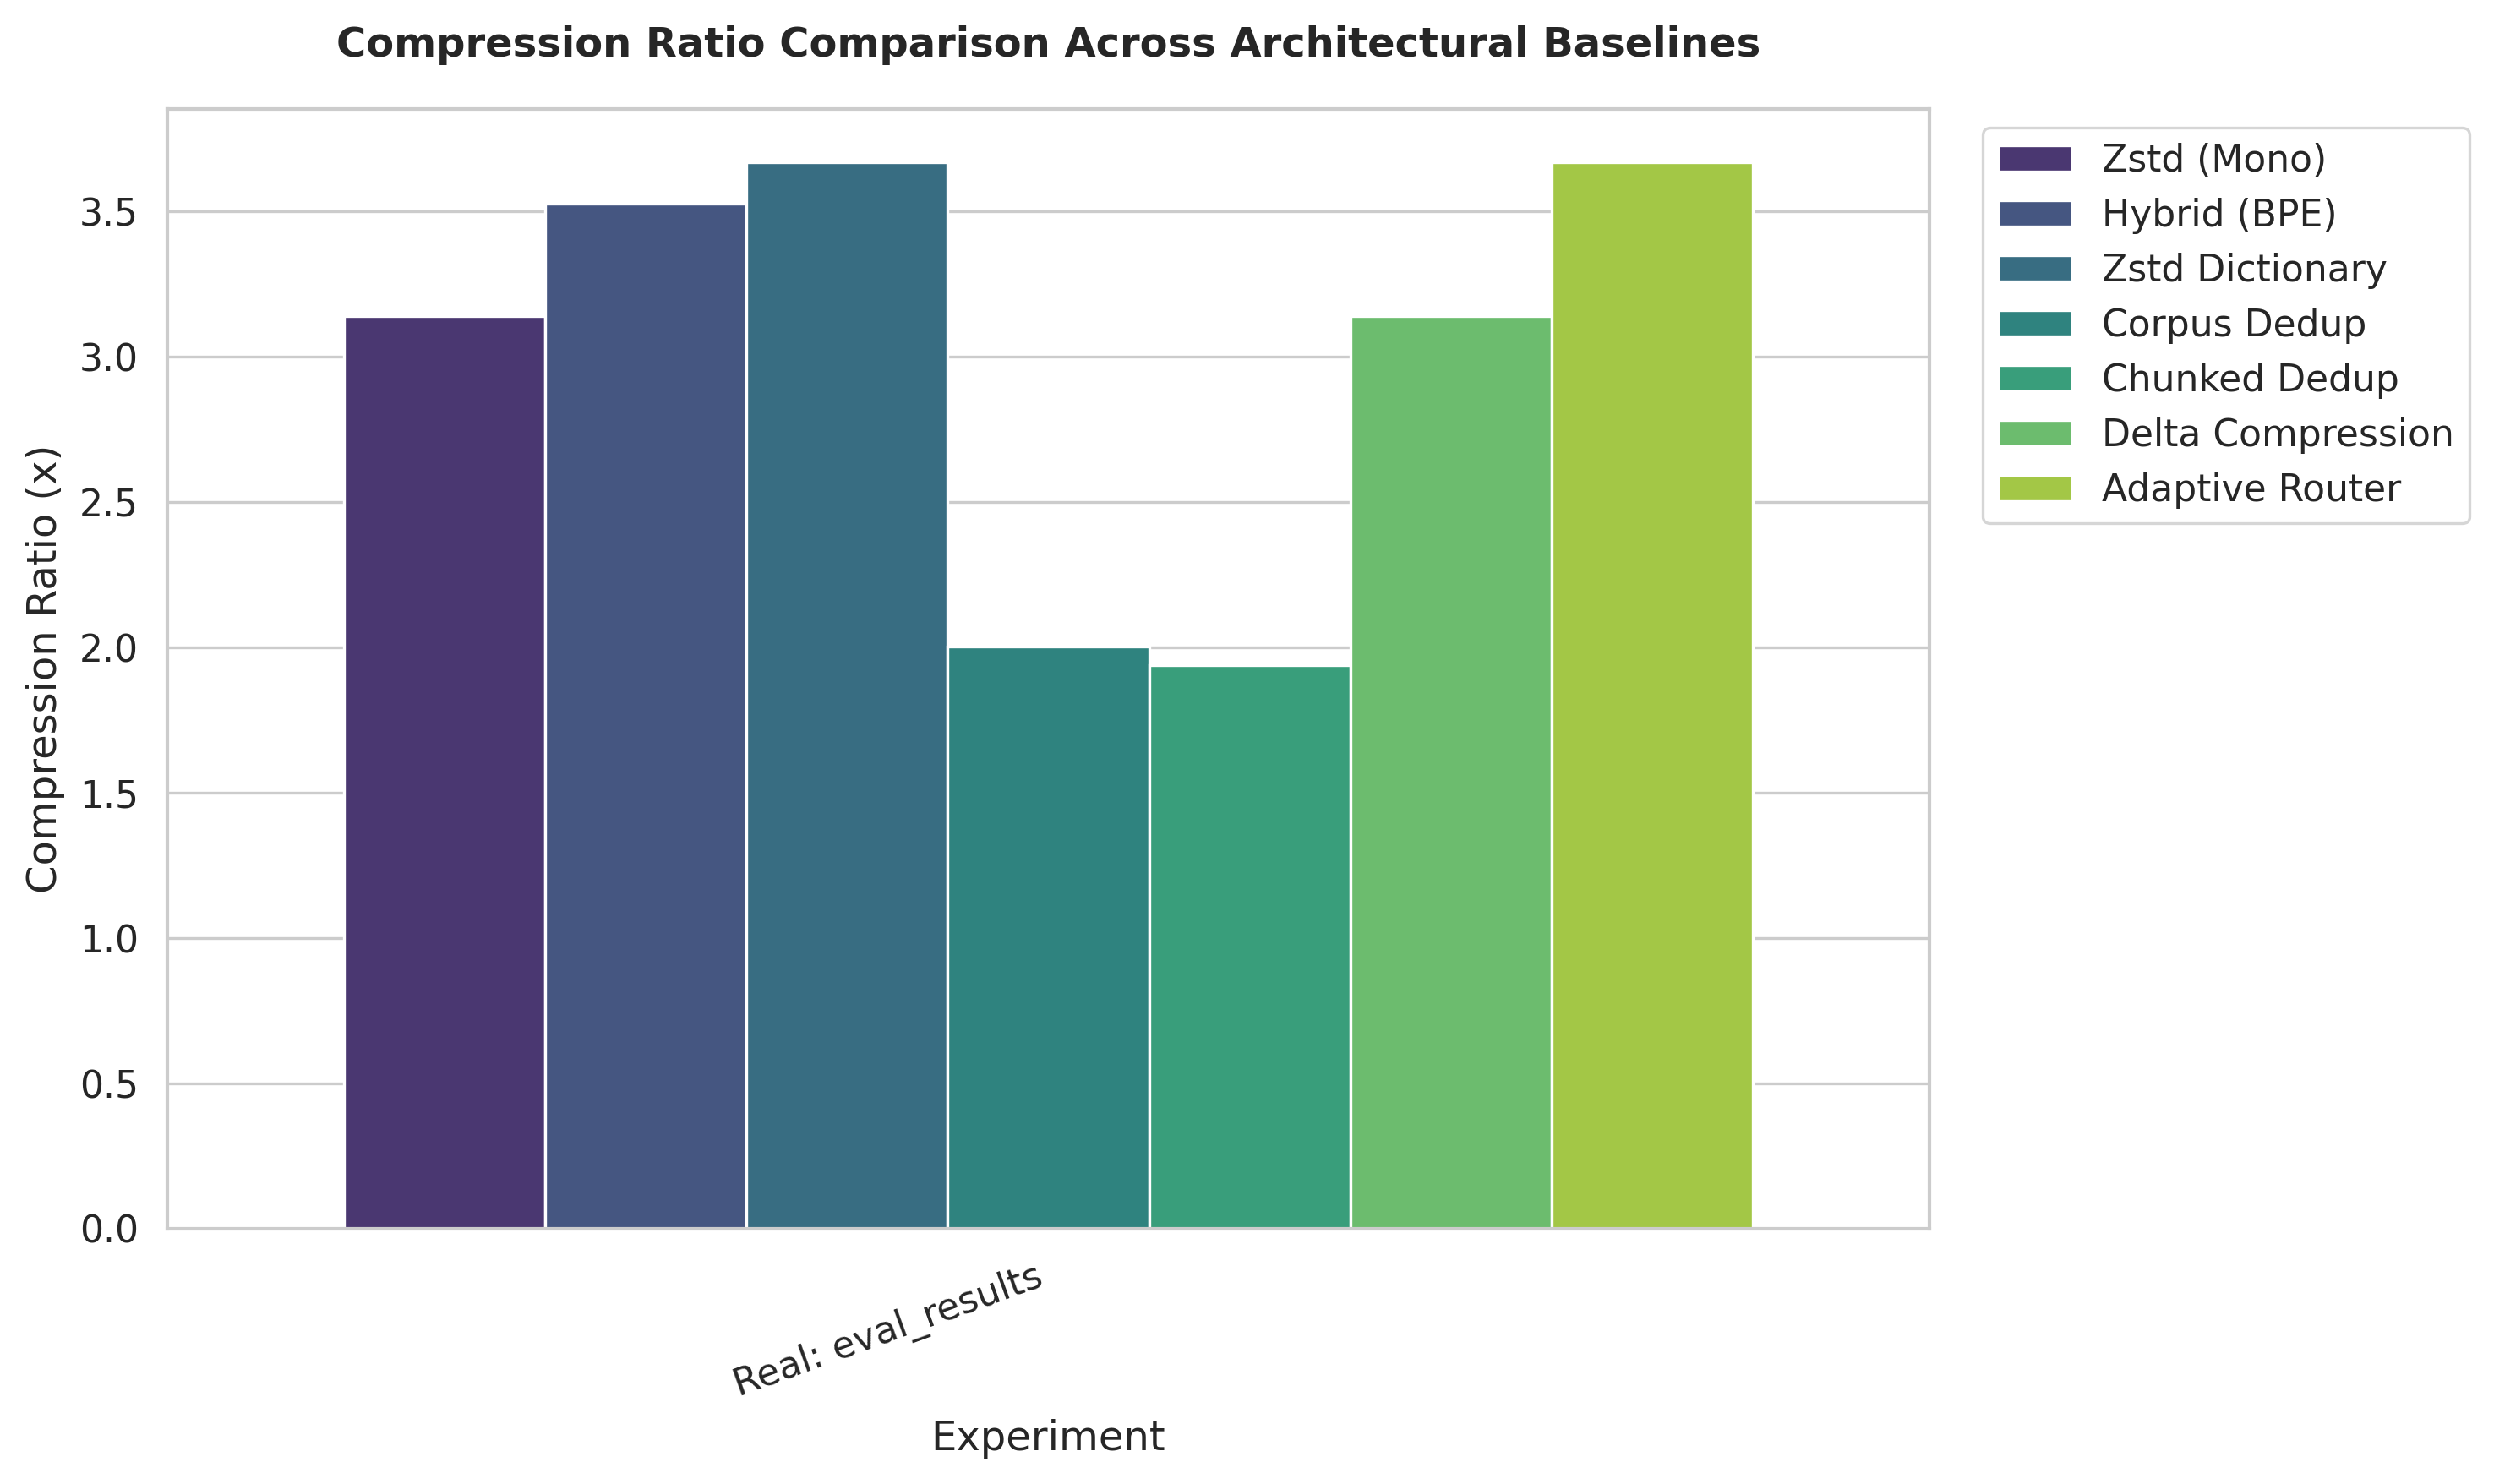

In [12]:
def plot_compression_ratios(json_file="benchmark_results.json"):
    try:
        with open(json_file, 'r') as f:
            data = json.load(f)
    except FileNotFoundError:
        print(f"Could not find {json_file}. Please run the benchmark script via CLI first!")
        return

    # Aggregate data
    experiments = []
    for exp in data.get('experiments', []):
        name = exp['experiment']
        methods = exp['methods']
        for method_id, stats in methods.items():
            if 'error' in stats: continue
            
            label_map = {
                'zstd': 'Zstd (Mono)',
                'hybrid': 'Hybrid (BPE)',
                'zstd_dict': 'Zstd Dictionary',
                'corpus_dedup': 'Corpus Dedup',
                'corpus_dedup_chunked': 'Chunked Dedup',
                'delta': 'Delta Compression',
                'adaptive': 'Adaptive Router'
            }
            
            ratio = stats.get('ratio', stats.get('ratio_with_dict', 0))
            experiments.append({
                'Experiment': name,
                'Method': label_map.get(method_id, method_id),
                'Compression Ratio (x)': ratio
            })

    if not experiments:
        print("No experiments found to plot.")
        return

    df = pd.DataFrame(experiments)
    
    # Plot
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(data=df, x='Experiment', y='Compression Ratio (x)', hue='Method', palette='viridis')
    plt.title('Compression Ratio Comparison Across Architectural Baselines', pad=15, fontweight='bold')
    plt.xticks(rotation=20, ha='right')
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    
    plt.savefig('compression_ratios.png')
    print("Saved figure to compression_ratios.png")
    plt.show()

plot_compression_ratios()

## 2. Storage Footprint Savings Overhead

/tmp/ipykernel_85005/3958253505.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=sizes_mb, palette='rocket')


Saved figure to storage_footprint.png


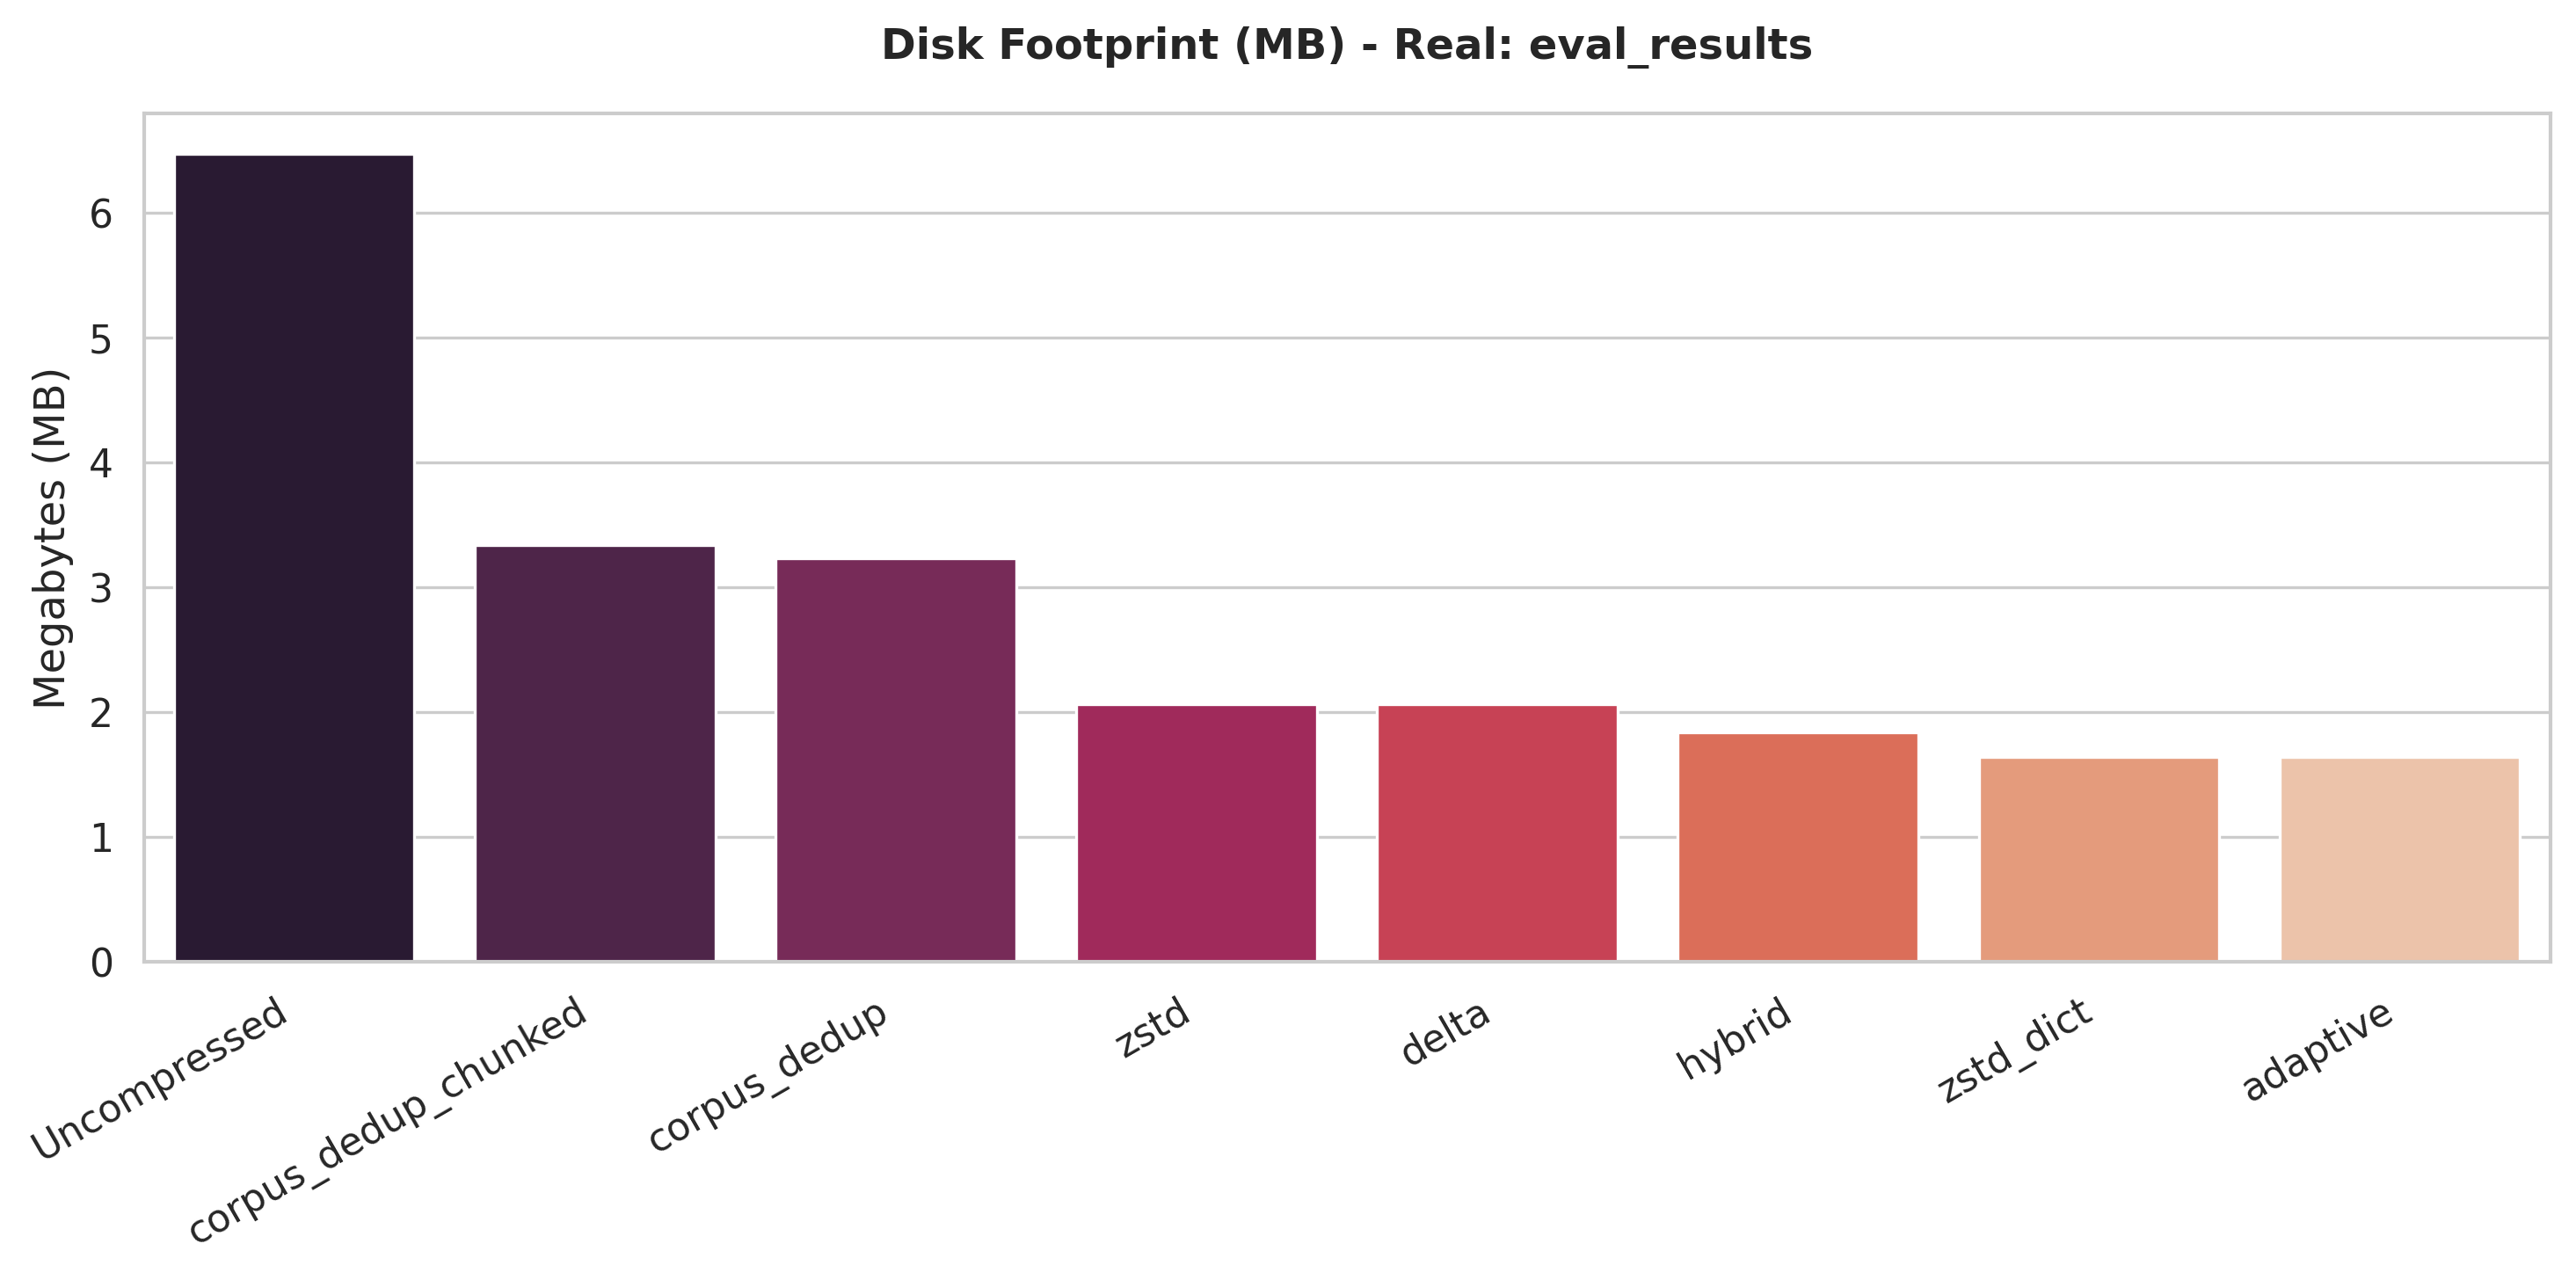

In [13]:
def plot_footprint(json_file="benchmark_results.json"):
    try:
        with open(json_file, 'r') as f:
            data = json.load(f)
    except FileNotFoundError:
        return

    if 'experiments' not in data or not data['experiments']:
        return

    exp = data['experiments'][-1]  # The latest run
    
    orig_size = 0
    methods_size = {}
    
    for m_id, stats in exp['methods'].items():
         orig_size = max(orig_size, stats.get('total_original', 0))
         comp = stats.get('total_compressed', stats.get('total_with_dict_overhead', 0))
         if comp > 0: methods_size[m_id] = comp

    methods_size['Uncompressed'] = orig_size
    methods_size = dict(sorted(methods_size.items(), key=lambda item: item[1], reverse=True))
    
    labels = list(methods_size.keys())
    sizes_mb = [s / (1024*1024) for s in methods_size.values()]

    plt.figure(figsize=(10, 5))
    sns.barplot(x=labels, y=sizes_mb, palette='rocket')
    plt.title(f"Disk Footprint (MB) - {exp['experiment']}", pad=15, fontweight='bold')
    plt.ylabel('Megabytes (MB)')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig('storage_footprint.png')
    print("Saved figure to storage_footprint.png")
    plt.show()

plot_footprint()